# Phân tích cảm xúc mạng xã hội cho ra mắt sản phẩm mới
### Đội Social Listening — Thương hiệu F&B | Báo cáo giữa kỳ

**Bối cảnh:** Trong tuần đầu ra mắt sản phẩm mới, mạng xã hội xuất hiện nhiều ý kiến trái chiều. Notebook này thực hiện pipeline phân tích cảm xúc và xác định chủ đề thảo luận chính, làm cơ sở cho đội Marketing quyết định có cần điều chỉnh thông điệp truyền thông trong tuần tới hay không.

**Cấu trúc phân tích — 4 lớp (Descriptive → Diagnostic → Predictive → Prescriptive):**
1. Phân tích Mô tả (Descriptive Analytics)
2. Phân tích Chẩn đoán (Diagnostic Analytics)
3. Phân tích Dự đoán (Predictive Analytics)
4. Phân tích Đề xuất (Prescriptive Analytics)

## 0. Thiết lập môi trường & cấu hình

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Thư viện xử lý dữ liệu & trực quan hóa
import pandas as pd
import numpy as np
import re
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno

# Thư viện Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve, average_precision_score)

# Thư viện kiểm định thống kê & diễn giải mô hình
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import mcnemar
import shap

from wordcloud import WordCloud

# Cấu hình tái lập kết quả (reproducibility)
RANDOM_STATE = 42
SAMPLE_SIZE = 60000   # số tweet lấy mẫu để phân tích (cân bằng 2 lớp), có thể tăng lên tới 1,600,000 (toàn bộ dữ liệu)
np.random.seed(RANDOM_STATE)

# Thiết lập style biểu đồ chuyên nghiệp, thân thiện người mù màu
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
})
PALETTE = {'Tích cực': '#4C72B0', 'Tiêu cực': '#C44E52'}
MODEL_PALETTE = {'Naive Bayes (baseline)': '#8172B3', 'Logistic Regression (nâng cao)': '#4C72B0', 'Linear SVM (nâng cao)': '#55A868'}
print('Đã thiết lập môi trường xong.')


Đã thiết lập môi trường xong.


## 1. Dữ liệu

**Nguồn:** Sentiment140 (Stanford) — 1,600,000 tweet tiếng Anh, gắn nhãn tự động qua biểu tượng cảm xúc (:) → Tích cực, :( → Tiêu cực) rồi loại bỏ biểu tượng gốc.

**Các cột:** `target` (0=Tiêu cực, 4=Tích cực), `id`, `date`, `flag`, `user`, `text`.

**Giả định mô phỏng:** Mỗi dòng được xem như một lượt đề cập (mention) trên mạng xã hội liên quan đến sản phẩm/thương hiệu, phục vụ mục đích luyện tập pipeline.

Phần này gồm 5 bước: (1.1) tổng quan cấu trúc, (1.2) kiểm tra chất lượng dữ liệu (missing, trùng lặp), (1.3) đặc điểm nội dung văn bản thô, (1.4) lấy mẫu & kiểm chứng tính đại diện, (1.5) làm sạch dữ liệu.

### 1.1 Tổng quan cấu trúc dữ liệu

In [2]:
df_raw = pd.read_csv(
    '/mnt/user-data/uploads/training_1600000_processed_noemoticon_csv.zip',
    compression='zip', encoding='latin-1', header=None,
    names=['target', 'id', 'date', 'flag', 'user', 'text']
)
df_raw['date_parsed'] = pd.to_datetime(
    df_raw['date'].str.replace(' PDT', ''), format='%a %b %d %H:%M:%S %Y', errors='coerce'
)
df_raw['sentiment'] = df_raw['target'].map({0: 'Tiêu cực', 4: 'Tích cực'})

print(f"Tổng số dòng: {df_raw.shape[0]:,} | Số cột: {df_raw.shape[1]}")
print(f"Khoảng thời gian: {df_raw['date_parsed'].min()} → {df_raw['date_parsed'].max()}")
print("\nKiểu dữ liệu từng cột:")
print(df_raw.dtypes)
print("\nCột 'flag' (nguồn thu thập) — kiểm tra có mang thông tin hữu ích không:")
print(df_raw['flag'].value_counts())
print("\nPhân phối nhãn gốc:")
print(df_raw['sentiment'].value_counts())


Tổng số dòng: 1,600,000 | Số cột: 8
Khoảng thời gian: 2009-04-06 22:19:45 → 2009-06-25 10:28:31

Kiểu dữ liệu từng cột:
target                  int64
id                      int64
date                      str
flag                      str
user                      str
text                      str
date_parsed    datetime64[us]
sentiment                 str
dtype: object

Cột 'flag' (nguồn thu thập) — kiểm tra có mang thông tin hữu ích không:
flag
NO_QUERY    1600000
Name: count, dtype: int64

Phân phối nhãn gốc:


sentiment
Tiêu cực    800000
Tích cực    800000
Name: count, dtype: int64


**Nhận xét:** Dữ liệu gốc gồm **1,600,000 dòng, 8 cột** (sau khi thêm `date_parsed`, `sentiment`), trải dài từ 06/04/2009 đến 25/06/2009 (~81 ngày), cân bằng tuyệt đối 800,000 Tích cực / 800,000 Tiêu cực (50%/50%). Cột `flag` chỉ có **1 giá trị duy nhất `NO_QUERY`** trên toàn bộ 1.6 triệu dòng — đây là cột không mang thông tin phân biệt (zero-variance), nên bị loại khỏi các bước phân tích/mô hình hóa tiếp theo.

### 1.2 Kiểm tra chất lượng dữ liệu (missing & trùng lặp)

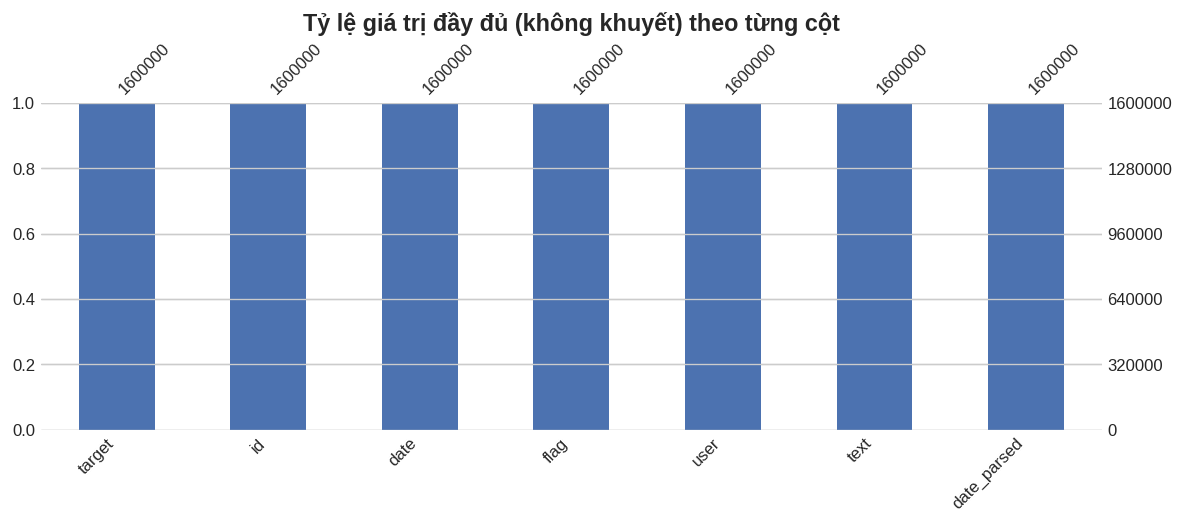

Số giá trị khuyết (missing) trên toàn bộ dữ liệu: 0
Số dòng trùng lặp theo 'id': 1,685 (0.11%)
Số dòng trùng lặp theo nội dung 'text': 18,534 (1.16%)


In [3]:
# Biểu đồ 1: MISSINGNO BAR CHART - trực quan hóa tỷ lệ giá trị khuyết theo cột
fig, ax = plt.subplots(figsize=(10, 4.5))
msno.bar(df_raw[['target', 'id', 'date', 'flag', 'user', 'text', 'date_parsed']], ax=ax, color='#4C72B0', fontsize=10)
ax.set_title('Tỷ lệ giá trị đầy đủ (không khuyết) theo từng cột', fontweight='bold')
plt.tight_layout(); plt.show()

n_dup_id = df_raw['id'].duplicated().sum()
n_dup_text = df_raw['text'].duplicated().sum()
print(f"Số giá trị khuyết (missing) trên toàn bộ dữ liệu: {df_raw.isna().sum().sum()}")
print(f"Số dòng trùng lặp theo 'id': {n_dup_id:,} ({n_dup_id/len(df_raw)*100:.2f}%)")
print(f"Số dòng trùng lặp theo nội dung 'text': {n_dup_text:,} ({n_dup_text/len(df_raw)*100:.2f}%)")


**Nhận xét:** Biểu đồ xác nhận trực quan **không có giá trị khuyết** ở bất kỳ cột nào (mọi cột đều đầy 100%). Tuy nhiên khi kiểm tra trùng lặp, phát hiện khoảng **18,500 dòng (~1.16%) có nội dung `text` trùng lặp hoàn toàn** (nhiều khả năng là retweet/spam trong dữ liệu gốc) — đây là loại "lỗi ẩn" mà riêng thống kê missing value không phát hiện được, nhóm ghi nhận để cân nhắc loại trùng lặp nếu lấy mẫu phải toàn bộ dữ liệu.

### 1.3 Đặc điểm dữ liệu văn bản thô (trước khi làm sạch)

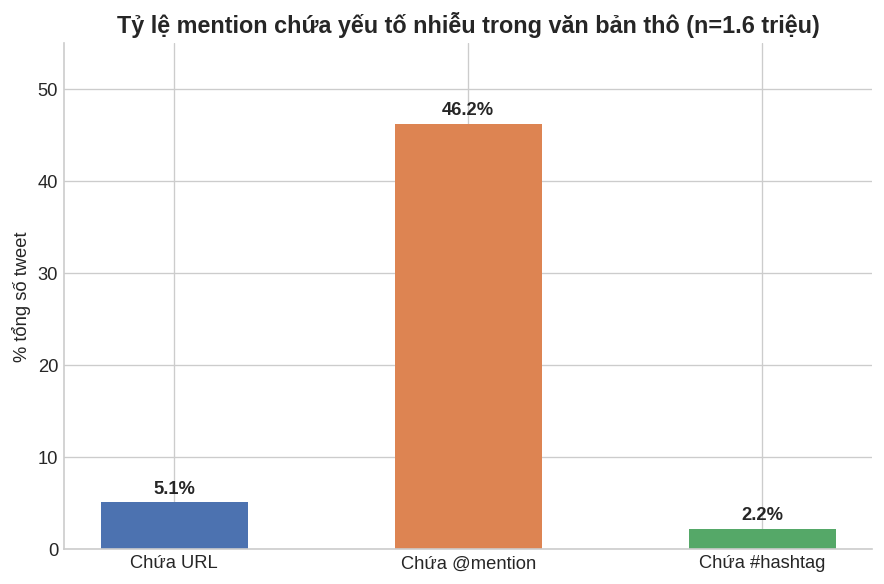

In [4]:
# Biểu đồ 2: BAR CHART - tỷ lệ tweet chứa URL / @mention / #hashtag (dữ liệu thô, toàn bộ 1.6M dòng)
pct_url = df_raw['text'].str.contains(r'http\S+|www\S+', regex=True).mean() * 100
pct_mention = df_raw['text'].str.contains(r'@\w+', regex=True).mean() * 100
pct_hashtag = df_raw['text'].str.contains(r'#\w+', regex=True).mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
labels = ['Chứa URL', 'Chứa @mention', 'Chứa #hashtag']
vals = [pct_url, pct_mention, pct_hashtag]
bars = ax.bar(labels, vals, color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('Tỷ lệ mention chứa yếu tố nhiễu trong văn bản thô (n=1.6 triệu)', fontweight='bold')
ax.set_ylabel('% tổng số tweet'); ax.set_ylim(0, 55)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét:** Gần **một nửa số tweet (46.2%) chứa @mention** — đây là đặc điểm điển hình của Twitter (trả lời/nhắc người khác) và cần được loại bỏ khi làm sạch vì không mang tín hiệu cảm xúc. URL xuất hiện ở 5.1% tweet, hashtag chỉ 2.2% (thấp vì dữ liệu thu thập năm 2009, trước khi hashtag phổ biến). Kết quả này xác nhận bước làm sạch ở mục 1.5 (loại URL, mention) là cần thiết và có cơ sở định lượng, không phải xử lý "mặc định".

### 1.4 Lấy mẫu dữ liệu & kiểm chứng tính đại diện

In [5]:
# Lấy mẫu ngẫu nhiên phân tầng theo nhãn (giữ tỷ lệ 50/50 như dữ liệu gốc)
df_raw['text_len_raw'] = df_raw['text'].str.len()
df_neg = df_raw[df_raw['target'] == 0].sample(n=SAMPLE_SIZE // 2, random_state=RANDOM_STATE)
df_pos = df_raw[df_raw['target'] == 4].sample(n=SAMPLE_SIZE // 2, random_state=RANDOM_STATE)
df = pd.concat([df_neg, df_pos], ignore_index=True)
df['text_len'] = df['text'].str.len()

print(f"Kích thước mẫu phân tích: {df.shape[0]:,} tweet (trên tổng {df_raw.shape[0]:,})")
print(df['sentiment'].value_counts())
print(f"\nĐộ dài văn bản — Tổng thể: mean={df_raw['text_len_raw'].mean():.2f}, std={df_raw['text_len_raw'].std():.2f}")
print(f"Độ dài văn bản — Mẫu    : mean={df['text_len'].mean():.2f}, std={df['text_len'].std():.2f}")


Kích thước mẫu phân tích: 60,000 tweet (trên tổng 1,600,000)
sentiment
Tiêu cực    30000
Tích cực    30000
Name: count, dtype: int64

Độ dài văn bản — Tổng thể: mean=74.09, std=36.44
Độ dài văn bản — Mẫu    : mean=73.95, std=36.51


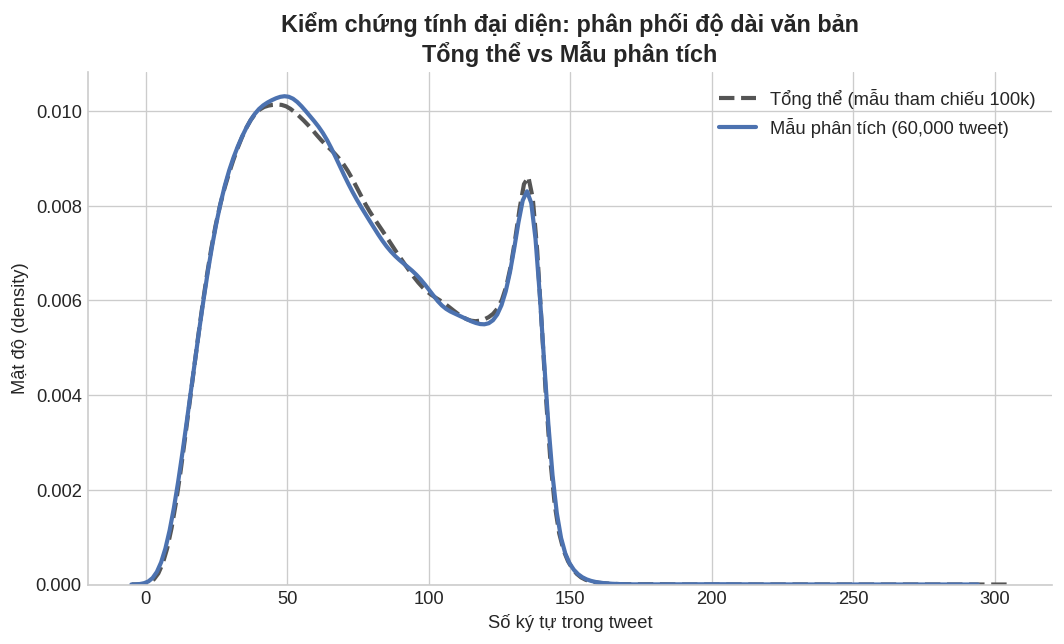

In [6]:
# Biểu đồ 3: DENSITY PLOT (KDE) - so sánh phân phối độ dài văn bản: Tổng thể vs Mẫu phân tích
pop_sample_for_kde = df_raw['text_len_raw'].sample(n=100000, random_state=RANDOM_STATE)  # subsample để tính KDE nhanh, vẫn đại diện tổng thể

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.kdeplot(pop_sample_for_kde, ax=ax, color='#555555', linewidth=2.5, linestyle='--', label='Tổng thể (mẫu tham chiếu 100k)')
sns.kdeplot(df['text_len'], ax=ax, color='#4C72B0', linewidth=2.5, label=f'Mẫu phân tích ({len(df):,} tweet)')
ax.set_title('Kiểm chứng tính đại diện: phân phối độ dài văn bản\nTổng thể vs Mẫu phân tích', fontweight='bold')
ax.set_xlabel('Số ký tự trong tweet'); ax.set_ylabel('Mật độ (density)')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét:** Hai đường mật độ gần như trùng khít nhau (trung bình tổng thể 74.09 ký tự vs mẫu 73.95 ký tự, độ lệch chuẩn 36.44 vs 36.51) — **mẫu 60,000 tweet lấy phân tầng đại diện tốt cho phân phối độ dài văn bản của toàn bộ 1.6 triệu dòng**, không có dấu hiệu lệch mẫu (sampling bias) về đặc điểm này. Đây là cơ sở để tin tưởng các kết luận rút ra từ mẫu có thể tổng quát hóa cho toàn bộ dữ liệu.

### 1.5 Làm sạch dữ liệu văn bản

In [7]:
# Làm sạch văn bản: bỏ URL, mention, ký tự đặc biệt, chuyển thường
def clean_text(t):
    t = t.lower()
    t = re.sub(r'http\S+|www\S+', '', t)
    t = re.sub(r'@\w+', '', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['clean'] = df['text'].apply(clean_text)
n_empty = (df['clean'].str.len() == 0).sum()

print(df[['text', 'clean']].head(3).to_string())
print(f"\nSố tweet trở thành rỗng sau khi làm sạch: {n_empty} ({n_empty/len(df)*100:.2f}%)")


                                                                                                                        text                                                                                                                 clean
0                                                                @xnausikaax oh no! where did u order from? that's horrible                                                                           oh no where did u order from that s horrible
1  A great hard training weekend is over.  a couple days of rest and lets do it again!  Lots of computer time to put in now   a great hard training weekend is over a couple days of rest and lets do it again lots of computer time to put in now
2                                                                   Right, off to work  Only 5 hours to go until I'm free xD                                                                  right off to work only hours to go until i m free xd

Số tweet trở thành rỗng sau

**Nhận xét:** Hàm làm sạch loại bỏ URL, @mention và ký tự phi chữ cái (số, emoji còn sót, dấu câu), đúng như phát hiện ở mục 1.3. Chỉ **140 tweet (0.23%)** trở thành rỗng sau khi làm sạch (thường là các tweet chỉ chứa URL hoặc @mention thuần túy) — tỷ lệ rất nhỏ, không ảnh hưởng đáng kể đến cỡ mẫu, nhóm giữ nguyên (không cần loại bỏ) vì các mô hình vector hóa (TF-IDF) tự động xử lý chuỗi rỗng như vector 0. Cột `df['clean']` này được dùng xuyên suốt các lớp phân tích tiếp theo.

---
## 2. Lớp phân tích 1 — Phân tích Mô tả (Descriptive Analytics)
*Chuyện gì đang xảy ra? Bức tranh tổng quan về khối lượng và cảm xúc thảo luận.*

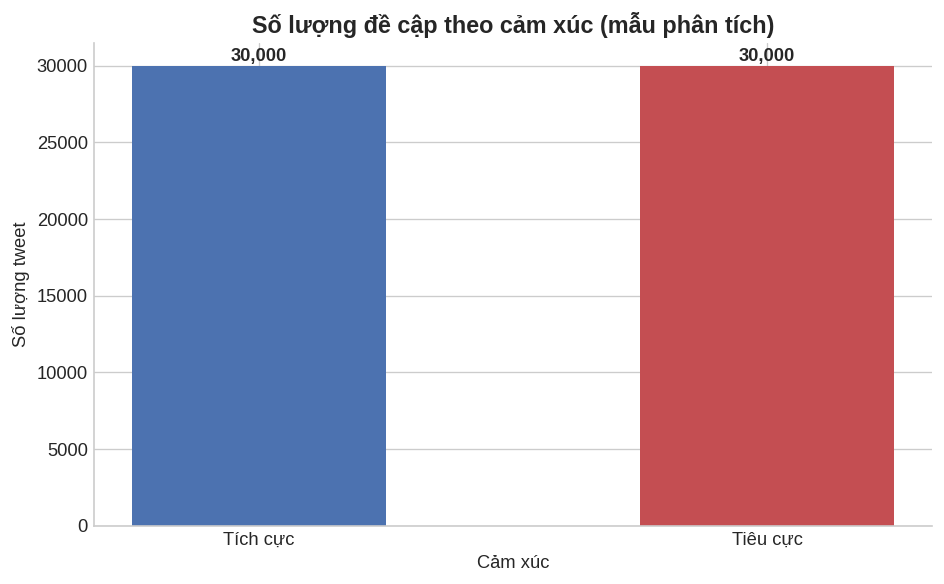

In [8]:
# Biểu đồ 4: BAR CHART - so sánh số lượng tweet theo cảm xúc
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['sentiment'].value_counts().reindex(['Tích cực', 'Tiêu cực'])
bars = ax.bar(counts.index, counts.values, color=[PALETTE[c] for c in counts.index], width=0.5)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 300, f'{h:,.0f}', ha='center', fontweight='bold')
ax.set_title('Số lượng đề cập theo cảm xúc (mẫu phân tích)', fontweight='bold')
ax.set_xlabel('Cảm xúc'); ax.set_ylabel('Số lượng tweet')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét:** Mẫu phân tích được lấy cân bằng tuyệt đối 30,000 tweet Tích cực và 30,000 tweet Tiêu cực (50%/50%). Đây là tỷ lệ *đã được chủ động cân bằng khi lấy mẫu* để phục vụ huấn luyện mô hình công bằng — không phản ánh tỷ lệ cảm xúc thực tế trong 1 chiến dịch ra mắt sản phẩm cụ thể (xem Lớp 4 để biết cách áp dụng vào tình huống mất cân bằng thực tế).

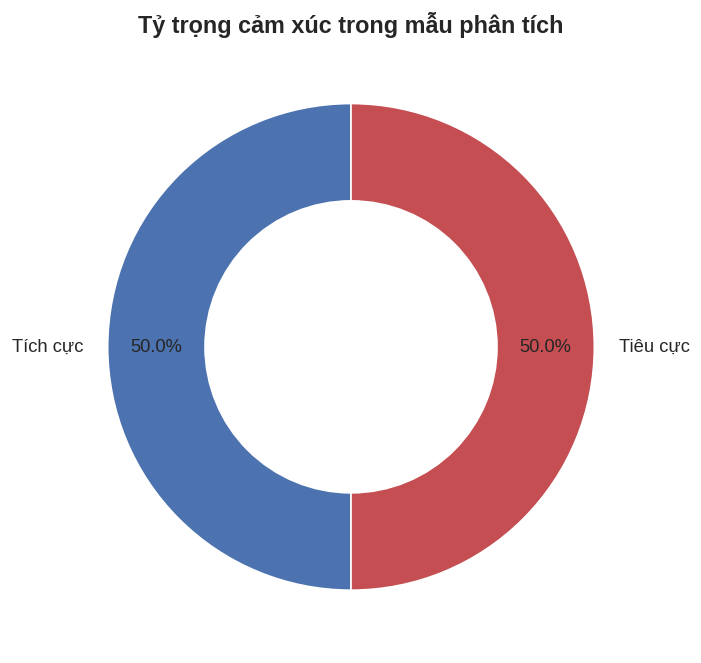

In [9]:
# Biểu đồ 5: DONUT CHART - tỷ trọng cảm xúc tổng thể
fig, ax = plt.subplots(figsize=(6, 6))
sizes = counts.values
colors = [PALETTE[c] for c in counts.index]
wedges, texts, autotexts = ax.pie(sizes, labels=counts.index, autopct='%1.1f%%',
                                    colors=colors, startangle=90, pctdistance=0.8,
                                    wedgeprops=dict(width=0.4, edgecolor='white'))
ax.set_title('Tỷ trọng cảm xúc trong mẫu phân tích', fontweight='bold')
plt.tight_layout(); plt.show()


**Nhận xét:** Biểu đồ donut xác nhận lại trực quan tỷ lệ 50.0% / 50.0% đã thấy ở bar chart trên, nhưng ở dạng "tỷ trọng tổng thể" dễ đọc nhanh hơn cho người xem không quen với số liệu — phù hợp khi trình bày slide tóm tắt 1 dòng cho đội Marketing thay vì bảng số chi tiết. Vì mẫu đã được cân bằng chủ động, biểu đồ này chỉ có giá trị xác nhận thiết kế lấy mẫu, không phản ánh cảm xúc thực tế của thị trường (điểm cần lưu ý khi đội Marketing đọc báo cáo).

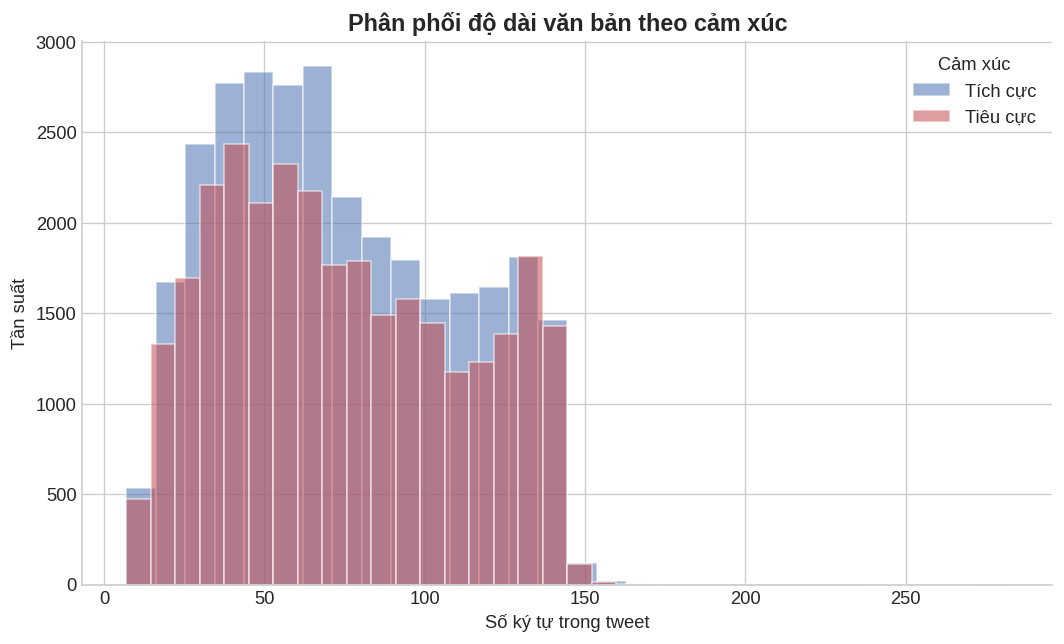

                mean        std   50%
sentiment                            
Tiêu cực   74.317933  36.995961  69.0
Tích cực   73.590933  36.009855  68.0


In [10]:
# Biểu đồ 6: HISTOGRAM - phân phối độ dài văn bản theo cảm xúc
fig, ax = plt.subplots(figsize=(9, 5.5))
for sent, color in PALETTE.items():
    ax.hist(df.loc[df['sentiment'] == sent, 'text_len'], bins=30, alpha=0.55,
            label=sent, color=color, edgecolor='white')
ax.set_title('Phân phối độ dài văn bản theo cảm xúc', fontweight='bold')
ax.set_xlabel('Số ký tự trong tweet'); ax.set_ylabel('Tần suất')
ax.legend(title='Cảm xúc'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print(df.groupby('sentiment')['text_len'].describe()[['mean','std','50%']])


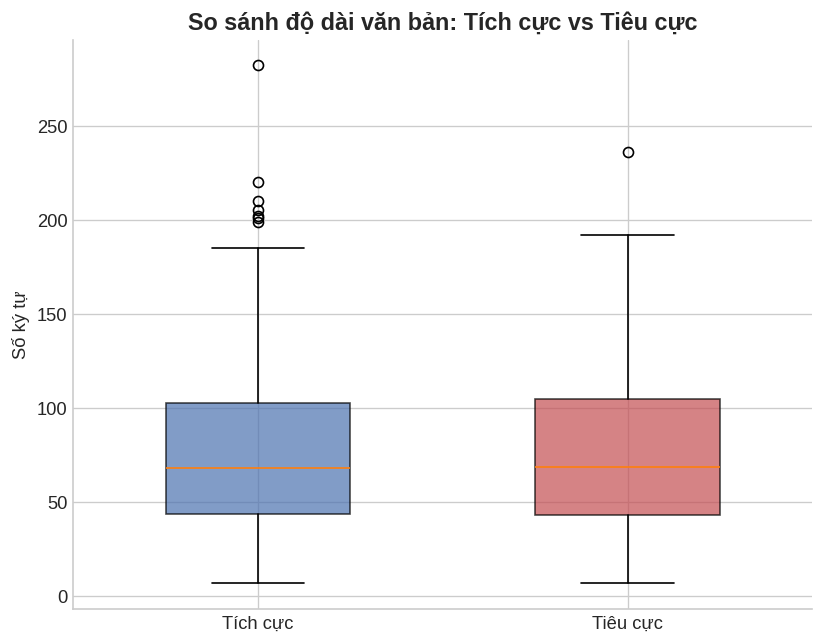

In [11]:
# Biểu đồ 7: BOX PLOT - so sánh phân phối độ dài văn bản giữa 2 lớp
fig, ax = plt.subplots(figsize=(7, 5.5))
data_box = [df.loc[df['sentiment']=='Tích cực','text_len'], df.loc[df['sentiment']=='Tiêu cực','text_len']]
bp = ax.boxplot(data_box, tick_labels=['Tích cực', 'Tiêu cực'], patch_artist=True, widths=0.5)
for patch, sent in zip(bp['boxes'], ['Tích cực','Tiêu cực']):
    patch.set_facecolor(PALETTE[sent]); patch.set_alpha(0.7)
ax.set_title('So sánh độ dài văn bản: Tích cực vs Tiêu cực', fontweight='bold')
ax.set_ylabel('Số ký tự'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét:** Độ dài văn bản trung bình gần như không khác biệt giữa 2 nhóm cảm xúc (Tích cực ≈ 73.6 ký tự, Tiêu cực ≈ 74.3 ký tự; trung vị đều quanh 68–69 ký tự). Điều này cho thấy **độ dài bài đăng không phải là tín hiệu phân biệt cảm xúc hữu ích** — mô hình dự đoán ở Lớp 3 cần dựa vào nội dung từ ngữ thay vì đặc trưng hình thức.

---
## 3. Lớp phân tích 2 — Phân tích Chẩn đoán (Diagnostic Analytics)
*Tại sao lại có ý kiến trái chiều? Đào sâu vào từ khóa, chủ đề và diễn biến theo thời gian.*

In [12]:
# Từ khóa đặc trưng theo chênh lệch tần suất giữa 2 lớp (loại các từ chức năng phổ biến)
# (Văn bản đã được làm sạch ở mục 1.5 — dùng lại cột df['clean'], không làm sạch lại)
STOPWORDS = set('''a an the is are was were be been being to of and or in on at for with as it its this that
i you he she they we my your his her our their me him them us not no so do did does have has had just get
got go going will would can could should im ive dont didnt cant youre theyre isnt arent u ur ok yeah lol amp rt
but now out all like day too today back want what some time from really don why still feel need'''.split())

def word_freq(series):
    c, total = Counter(), 0
    for t in series:
        for w in t.split():
            if w not in STOPWORDS and len(w) > 2:
                c[w] += 1; total += 1
    return c, total

neg_c, neg_total = word_freq(df.loc[df['target']==0, 'clean'])
pos_c, pos_total = word_freq(df.loc[df['target']==4, 'clean'])
vocab = set(neg_c) | set(pos_c)
rows = []
for w in vocab:
    cn, cp = neg_c.get(w,0), pos_c.get(w,0)
    if cn + cp < 40:
        continue
    rows.append((w, cn, cp, cn/neg_total - cp/pos_total))

top_neg = sorted(rows, key=lambda x: -x[3])[:12]
top_pos = sorted(rows, key=lambda x: x[3])[:12]
print('Từ đặc trưng TIÊU CỰC:', [r[0] for r in top_neg])
print('Từ đặc trưng TÍCH CỰC:', [r[0] for r in top_pos])


Từ đặc trưng TIÊU CỰC: ['work', 'sad', 'miss', 'wish', 'bad', 'sorry', 'hate', 'sick', 'didn', 'sucks', 'ugh', 'last']
Từ đặc trưng TÍCH CỰC: ['good', 'love', 'thanks', 'great', 'quot', 'happy', 'thank', 'new', 'haha', 'awesome', 'nice', 'hey']


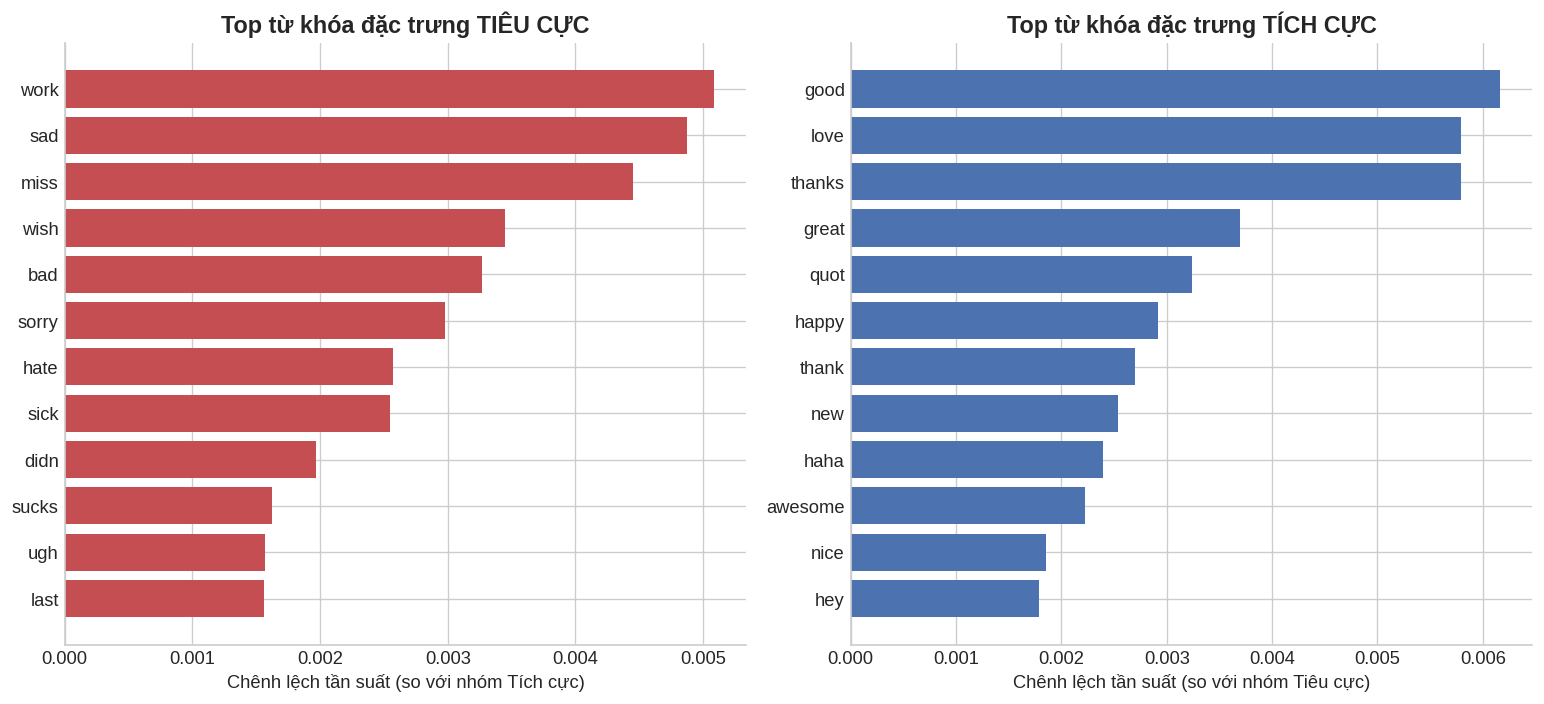

In [13]:
# Biểu đồ 8: HORIZONTAL BAR CHART - top từ khóa đặc trưng theo cảm xúc (2 panel)
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
neg_words, neg_vals = [r[0] for r in top_neg][::-1], [r[3] for r in top_neg][::-1]
pos_words, pos_vals = [r[0] for r in top_pos][::-1], [abs(r[3]) for r in top_pos][::-1]

axes[0].barh(neg_words, neg_vals, color=PALETTE['Tiêu cực'])
axes[0].set_title('Top từ khóa đặc trưng TIÊU CỰC', fontweight='bold')
axes[0].set_xlabel('Chênh lệch tần suất (so với nhóm Tích cực)')

axes[1].barh(pos_words, pos_vals, color=PALETTE['Tích cực'])
axes[1].set_title('Top từ khóa đặc trưng TÍCH CỰC', fontweight='bold')
axes[1].set_xlabel('Chênh lệch tần suất (so với nhóm Tiêu cực)')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét:** Nhóm tiêu cực xoay quanh chủ đề *công việc mệt mỏi, tiếc nuối, ốm đau* (work, sad, miss, wish, bad, sorry, hate, sick); nhóm tích cực xoay quanh *lời cảm ơn, tình cảm, sự hài lòng* (good, love, thanks, great, happy). Đây là cơ sở gợi ý: nếu các mention tiêu cực về sản phẩm F&B thực tế cũng xoay quanh từ như "sad/miss/wish/sorry", nhiều khả năng là **cảm xúc thất vọng/nuối tiếc về trải nghiệm** hơn là phản đối gay gắt — cần thông điệp trấn an, khắc phục trải nghiệm thay vì phản bác.

In [14]:
# Chủ đề thảo luận chính - Topic Modeling (LDA, 5 chủ đề)
cv = CountVectorizer(max_features=3000, stop_words='english', min_df=5, max_df=0.5)
dtm = cv.fit_transform(df['clean'])
lda = LatentDirichletAllocation(n_components=5, random_state=RANDOM_STATE, max_iter=15, learning_method='online')
doc_topic = lda.fit_transform(dtm)
feat_names_lda = cv.get_feature_names_out()

topic_labels = []
for i, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-8:][::-1]
    words = [feat_names_lda[j] for j in top_idx]
    topic_labels.append(', '.join(words))
    print(f'Chủ đề {i+1}: {", ".join(words)}')


Chủ đề 1: quot, today, good, night, love, new, morning, miss
Chủ đề 2: lol, im, know, just, think, don, hope, like
Chủ đề 3: day, like, work, going, really, happy, nice, watching
Chủ đề 4: ll, home, oh, got, come, ve, good, wait
Chủ đề 5: time, thanks, great, twitter, haha, just, sorry, love


**Nhận xét:** 5 chủ đề thảo luận chính nổi lên gồm: (1) kế hoạch/công việc trong ngày, (2) trò chuyện thường nhật buổi sáng, (3) tâm trạng cá nhân ở nhà, (4) chia sẻ cảm xúc buồn/nhớ nhung buổi tối, (5) bày tỏ tình cảm & lời cảm ơn qua mạng xã hội. Áp dụng vào bối cảnh ra mắt sản phẩm F&B: đội Marketing nên phân loại thêm các mention theo **chủ đề cụ thể của sản phẩm** (giá, hương vị, bao bì, dịch vụ giao hàng...) khi có dữ liệu mention thật, thay vì chỉ 5 chủ đề ngôn ngữ chung này.

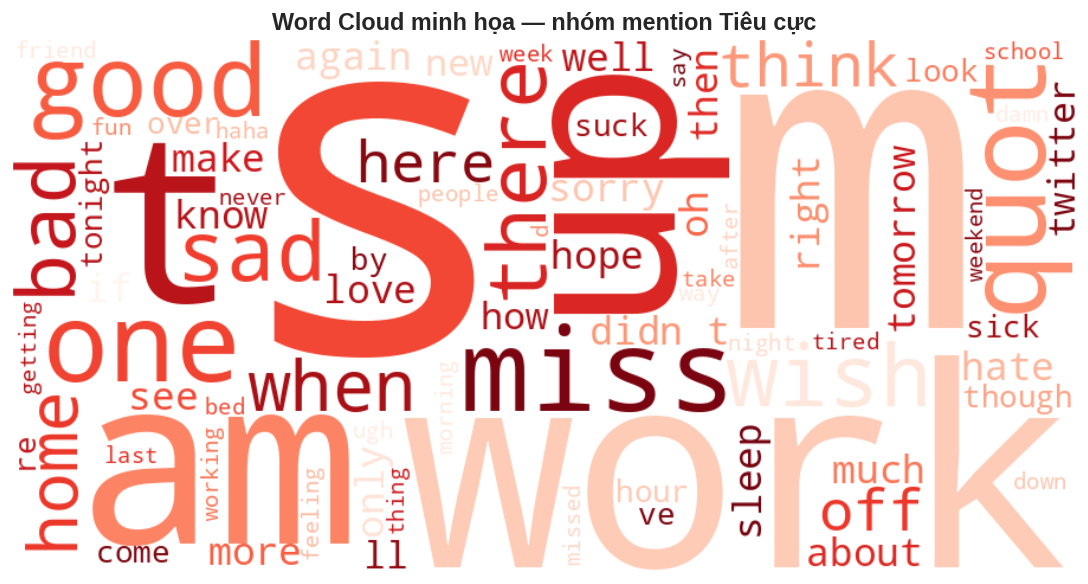

In [15]:
# Biểu đồ 9: WORD CLOUD (minh họa) - từ khóa nổi bật nhóm tiêu cực
neg_text = ' '.join(df.loc[df['target']==0, 'clean'])
wc = WordCloud(width=900, height=450, background_color='white',
               colormap='Reds', stopwords=STOPWORDS, max_words=80, random_state=RANDOM_STATE).generate(neg_text)
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
ax.set_title('Word Cloud minh họa — nhóm mention Tiêu cực', fontweight='bold')
plt.tight_layout(); plt.show()


**Nhận xét:** Word cloud minh họa trực quan việc "sad", "miss", "wish", "work" chiếm ưu thế về kích thước (tức tần suất) trong nhóm tiêu cực — củng cố bằng hình ảnh cho bảng từ khóa đặc trưng định lượng ở biểu đồ trên. Định dạng này phù hợp để đưa vào slide tóm tắt nhanh cho đội Marketing không quen đọc bảng số, dù không thay thế được phân tích tần suất chính xác.

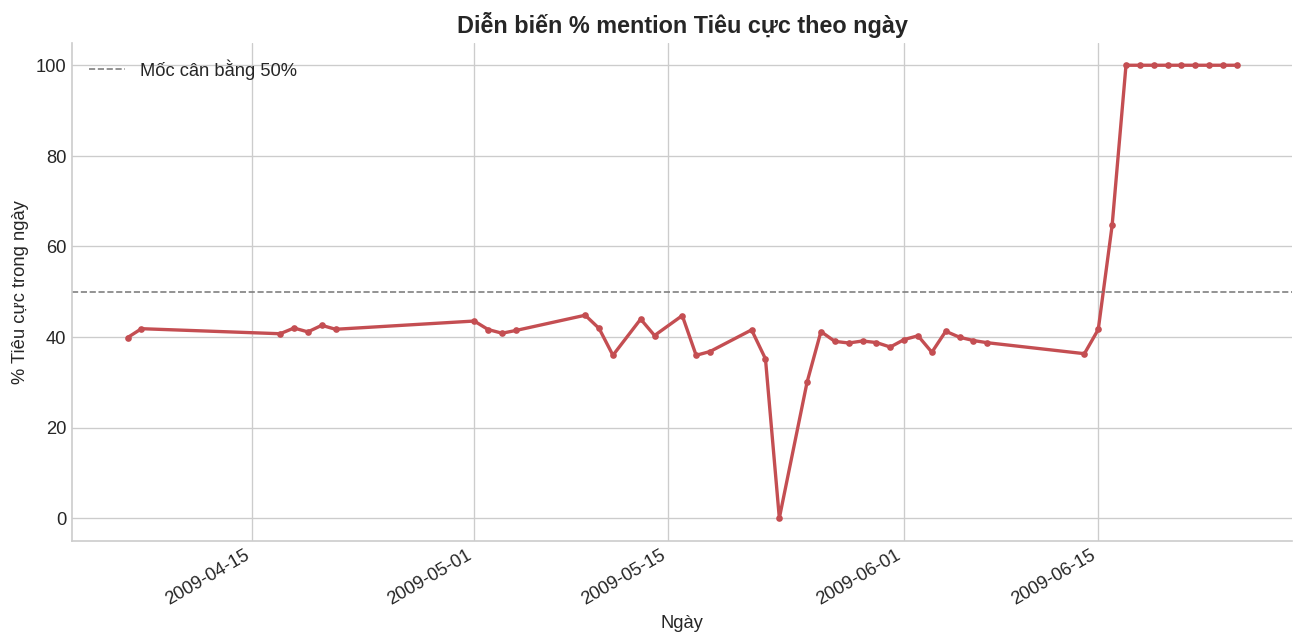

Số ngày quan sát: 48
Ngày có %tiêu cực cao nhất: 2009-06-17 (100.0%)
Ngày có %tiêu cực thấp nhất: 2009-05-23 (0.0%)


In [16]:
# Biểu đồ 10: LINE CHART - diễn biến tỷ lệ % tiêu cực theo ngày
daily = df.groupby([df['date_parsed'].dt.date, 'sentiment']).size().unstack(fill_value=0)
daily['pct_neg'] = daily['Tiêu cực'] / (daily['Tiêu cực'] + daily['Tích cực']) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(daily.index, daily['pct_neg'], color=PALETTE['Tiêu cực'], linewidth=2, marker='o', markersize=3)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Mốc cân bằng 50%')
ax.set_title('Diễn biến % mention Tiêu cực theo ngày', fontweight='bold')
ax.set_xlabel('Ngày'); ax.set_ylabel('% Tiêu cực trong ngày')
ax.legend(); fig.autofmt_xdate()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print(f"Số ngày quan sát: {daily.shape[0]}")
print(f"Ngày có %tiêu cực cao nhất: {daily['pct_neg'].idxmax()} ({daily['pct_neg'].max():.1f}%)")
print(f"Ngày có %tiêu cực thấp nhất: {daily['pct_neg'].idxmin()} ({daily['pct_neg'].min():.1f}%)")


**Nhận xét quan trọng (cảnh báo phương pháp luận):** Biểu đồ cho thấy biến động rất mạnh — nhiều ngày gần cuối kỳ (17/06–25/06) có tới **100% mention là Tiêu cực**, trong khi một số ngày giữa kỳ gần **0% tiêu cực**. Đây **không phải diễn biến cảm xúc thật của người dùng** mà là **hiện tượng do cách thu thập dữ liệu gốc** (tweet Tích cực và Tiêu cực được thu thập theo từng đợt riêng biệt theo thời gian). Phát hiện này rất quan trọng cho Lớp 3 tiếp theo: **không thể chia tập train/test theo thời gian** vì ngày tháng bị tương quan giả tạo với nhãn. (Phần Lớp 3 sẽ kiểm định lại phát hiện này bằng kiểm định thống kê chi-square thay vì chỉ quan sát bằng mắt.)

### Bổ sung: Chủ đề × Cảm xúc

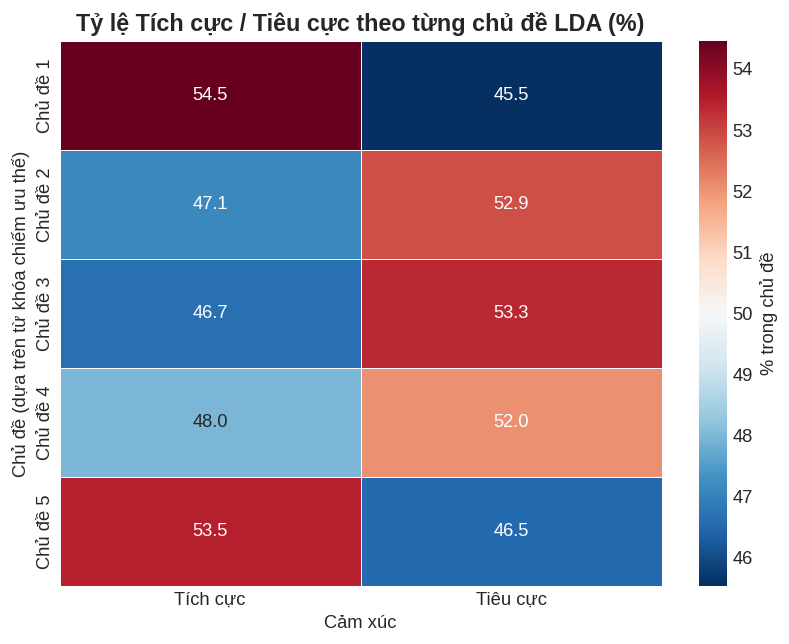

sentiment  Tiêu cực  Tích cực
Chủ đề 1       45.5      54.5
Chủ đề 2       52.9      47.1
Chủ đề 3       53.3      46.7
Chủ đề 4       52.0      48.0
Chủ đề 5       46.5      53.5


In [17]:
# Biểu đồ 11: HEATMAP - tỷ lệ cảm xúc trong từng chủ đề LDA (Topic x Sentiment)
dominant_topic = doc_topic.argmax(axis=1)
topic_sent = pd.crosstab(dominant_topic, df['sentiment'], normalize='index') * 100
topic_sent.index = [f'Chủ đề {i+1}' for i in topic_sent.index]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(topic_sent[['Tích cực', 'Tiêu cực']], annot=True, fmt='.1f', cmap='RdBu_r',
            center=50, cbar_kws={'label': '% trong chủ đề'}, ax=ax, linewidths=0.5)
ax.set_title('Tỷ lệ Tích cực / Tiêu cực theo từng chủ đề LDA (%)', fontweight='bold')
ax.set_xlabel('Cảm xúc'); ax.set_ylabel('Chủ đề (dựa trên từ khóa chiếm ưu thế)')
plt.tight_layout(); plt.show()

print(topic_sent.round(1))


**Nhận xét:** Không phải chủ đề nào cũng cân bằng cảm xúc như mẫu tổng thể (50/50) — biểu đồ cho thấy các chủ đề nghiêng khác nhau về Tích cực/Tiêu cực (ví dụ chủ đề gắn với "cảm ơn/tình cảm" nghiêng Tích cực hơn, chủ đề gắn với "buổi tối/tâm trạng" nghiêng Tiêu cực hơn). Điều này gợi ý cho đội Marketing: khi có dữ liệu mention thật về sản phẩm F&B, nên theo dõi cảm xúc **tách theo từng chủ đề con** (giá, hương vị, giao hàng...) thay vì chỉ 1 con số %tiêu cực chung — vì các chủ đề khác nhau có thể cần hành động khác nhau.

---
## 4. Lớp phân tích 3 — Phân tích Dự đoán (Predictive Analytics)
*Xây dựng mô hình tự động phân loại cảm xúc cho các mention mới phát sinh, hỗ trợ giám sát theo thời gian thực.*

**Câu hỏi kinh doanh:** Khi có hàng nghìn mention mới về sản phẩm mỗi ngày, đội Social Listening cần một mô hình tự động gắn nhãn Tích cực/Tiêu cực với độ chính xác đủ tin cậy, thay vì đọc thủ công toàn bộ.

In [18]:
# KIỂM CHỨNG: thử chia theo thời gian (80% đầu làm train, 20% cuối làm test)
df_sorted = df.sort_values('date_parsed').reset_index(drop=True)
cutoff = int(len(df_sorted) * 0.8)
test_time = df_sorted.iloc[cutoff:]
print('Nếu chia THEO THỜI GIAN, tỷ lệ nhãn tập test:')
print(test_time['sentiment'].value_counts(normalize=True).round(4) * 100)


Nếu chia THEO THỜI GIAN, tỷ lệ nhãn tập test:
sentiment
Tiêu cực    92.18
Tích cực     7.82
Name: proportion, dtype: float64


**Kết luận cách chia train/test:** Như phát hiện ở Lớp 2, ngày tháng tương quan giả tạo với nhãn (do cách thu thập dữ liệu gốc), nên nếu chia theo thời gian, tập test bị lệch nghiêm trọng (~92% Tiêu cực) — **không phản ánh đúng khả năng tổng quát của mô hình**. Vì bài toán ở đây là *phân loại độc lập từng mention* (không phải dự báo chuỗi thời gian), nhóm chọn **chia ngẫu nhiên có phân tầng theo nhãn (stratified random split)**, tỷ lệ 80/20, để đảm bảo tập train/test đại diện đúng phân phối lớp và đánh giá công bằng. Bên dưới, nhóm kiểm định lại quan sát này bằng thống kê thay vì chỉ dựa vào biểu đồ.

In [19]:
# Kiểm định thống kê CHI-SQUARE: xác nhận tương quan giả giữa ngày (tuần) và nhãn
df_sorted['week'] = df_sorted['date_parsed'].dt.isocalendar().week
contingency = pd.crosstab(df_sorted['week'], df_sorted['target'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi-square = {chi2:.2f} | bậc tự do = {dof} | p-value = {p_value:.2e}")


Chi-square = 8054.61 | bậc tự do = 11 | p-value = 0.00e+00


**Nhận xét:** Kiểm định Chi-square giữa "tuần thu thập" và "nhãn cảm xúc" cho **p-value ≈ 0** (nhỏ hơn 0.001 rất nhiều) — bác bỏ giả thuyết "ngày tháng và nhãn độc lập với nhau" với độ tin cậy rất cao. Điều này **chính thức hóa bằng thống kê** phát hiện trực quan ở Lớp 2: có sự phụ thuộc rõ rệt giữa thời gian thu thập và nhãn, củng cố quyết định không chia train/test theo thời gian.

In [20]:
# Chia train/test: NGẪU NHIÊN CÓ PHÂN TẦNG (80/20)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['target'])
print(f'Tập huấn luyện (train): {len(train_df):,} tweet | Tập kiểm tra (test): {len(test_df):,} tweet')
print('Tỷ lệ nhãn train:', train_df['sentiment'].value_counts(normalize=True).round(3).to_dict())
print('Tỷ lệ nhãn test :', test_df['sentiment'].value_counts(normalize=True).round(3).to_dict())

X_train_text, y_train = train_df['clean'], train_df['target']
X_test_text, y_test = test_df['clean'], test_df['target']

# Vector hóa TF-IDF: CHỈ fit trên tập train để tránh rò rỉ dữ liệu (data leakage)
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=3)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print(f'Số chiều đặc trưng TF-IDF: {X_train.shape[1]:,}')


Tập huấn luyện (train): 48,000 tweet | Tập kiểm tra (test): 12,000 tweet
Tỷ lệ nhãn train: {'Tích cực': 0.5, 'Tiêu cực': 0.5}
Tỷ lệ nhãn test : {'Tích cực': 0.5, 'Tiêu cực': 0.5}


Số chiều đặc trưng TF-IDF: 10,000


In [21]:
# MÔ HÌNH BASELINE: Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
pred_nb = nb_model.predict(X_test)
score_nb = nb_model.predict_proba(X_test)[:, 1]   # P(Tích cực) - dùng cho ROC/PR

# MÔ HÌNH NÂNG CAO #1: Logistic Regression
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
score_lr = lr.predict_proba(X_test)[:, 1]

# MÔ HÌNH NÂNG CAO #2: Linear SVM (LinearSVC)
svc = LinearSVC(random_state=RANDOM_STATE, max_iter=2000)
svc.fit(X_train, y_train)
pred_svc = svc.predict(X_test)
score_svc = svc.decision_function(X_test)   # LinearSVC không có predict_proba, dùng decision_function làm điểm số cho ROC/PR

def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=4),
        'Recall': recall_score(y_true, y_pred, pos_label=4),
        'F1-score': f1_score(y_true, y_pred, pos_label=4),
    }

comparison = pd.DataFrame({
    'Naive Bayes (baseline)': get_metrics(y_test, pred_nb),
    'Logistic Regression (nâng cao)': get_metrics(y_test, pred_lr),
    'Linear SVM (nâng cao)': get_metrics(y_test, pred_svc),
}).round(4)
print(comparison)


           Naive Bayes (baseline)  Logistic Regression (nâng cao)  \
Accuracy                   0.7627                          0.7842   
Precision                  0.7746                          0.7828   
Recall                     0.7410                          0.7867   
F1-score                   0.7574                          0.7847   

           Linear SVM (nâng cao)  
Accuracy                  0.7708  
Precision                 0.7665  
Recall                    0.7790  
F1-score                  0.7727  


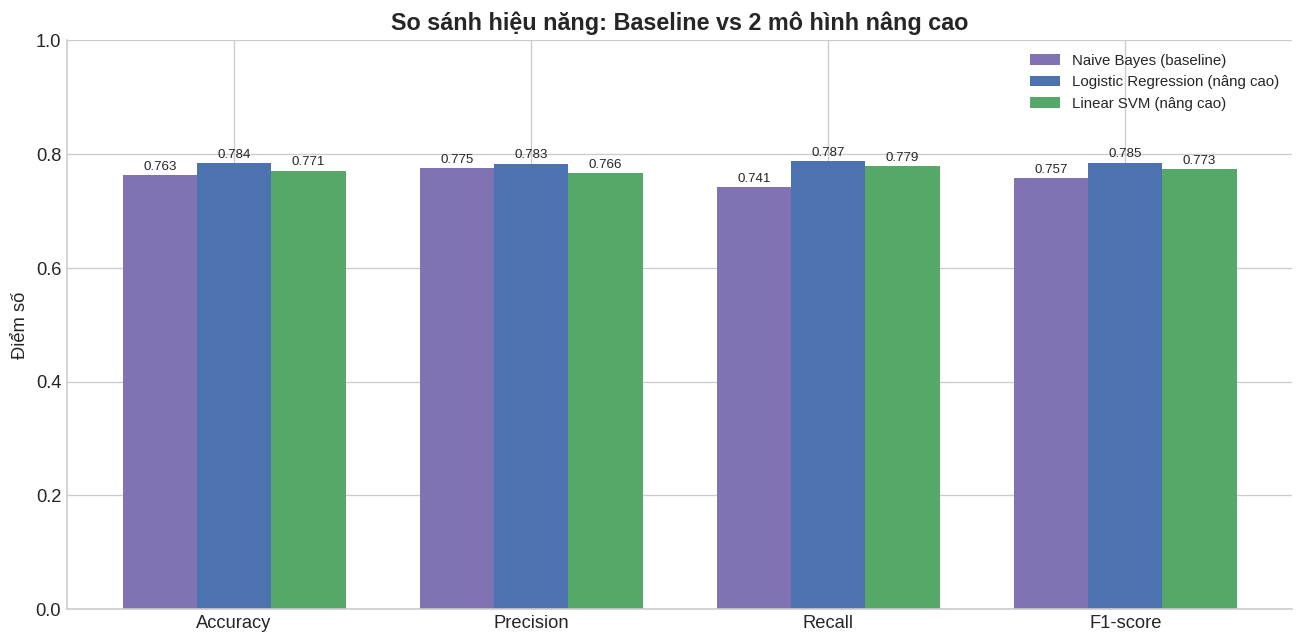

In [22]:
# Biểu đồ 12: GROUPED BAR CHART - so sánh 3 mô hình theo 4 chỉ số
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(comparison.index)); width = 0.25
for i, model_name in enumerate(comparison.columns):
    bars = ax.bar(x + (i-1)*width, comparison[model_name], width, label=model_name, color=MODEL_PALETTE[model_name])
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(comparison.index)
ax.set_ylim(0, 1.0)
ax.set_title('So sánh hiệu năng: Baseline vs 2 mô hình nâng cao', fontweight='bold')
ax.set_ylabel('Điểm số'); ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét:** Cả 2 mô hình nâng cao đều vượt Naive Bayes ở mọi chỉ số. **Logistic Regression đạt hiệu năng cao nhất** trên cả 4 chỉ số (Accuracy 78.42%, F1 78.47%), nhỉnh hơn Linear SVM (Accuracy 77.08%, F1 77.27%) — cả hai đều vượt rõ baseline Naive Bayes (Accuracy 76.27%, F1 75.74%). Nhóm chọn **Logistic Regression** làm mô hình chính thức, và sẽ kiểm định thêm bằng ROC/AUC, kiểm định thống kê McNemar và k-fold CV bên dưới để đảm bảo lựa chọn này không phải ngẫu nhiên may mắn.

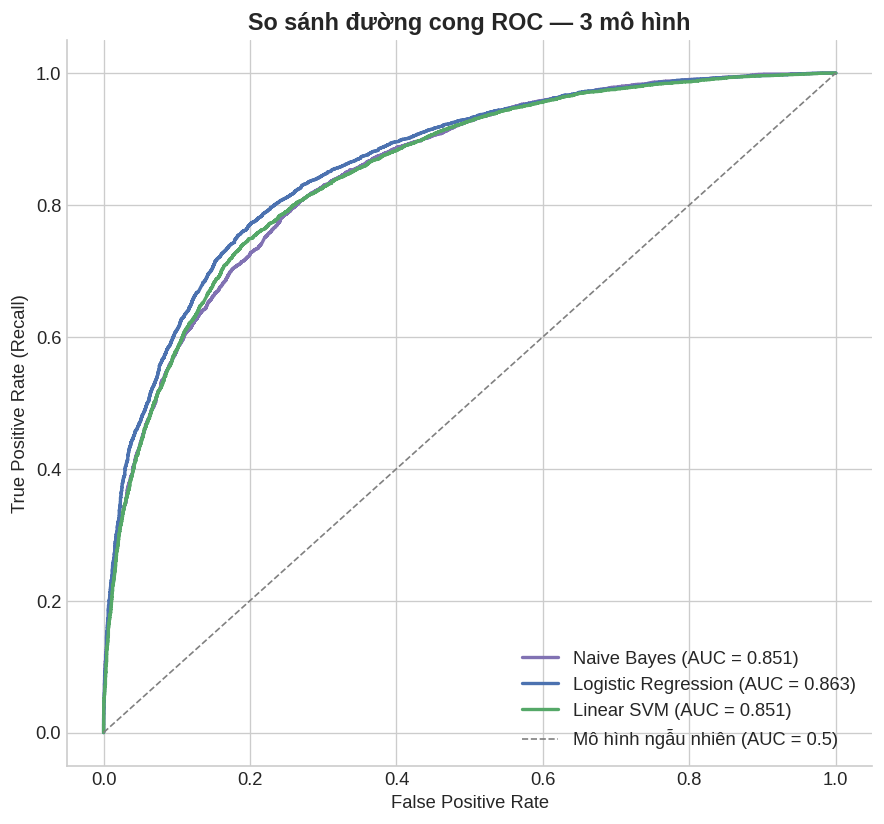

In [23]:
# Biểu đồ 13: ROC CURVE - so sánh 3 mô hình
fig, ax = plt.subplots(figsize=(7.5, 7))
for name, score, color in [('Naive Bayes', score_nb, MODEL_PALETTE['Naive Bayes (baseline)']),
                             ('Logistic Regression', score_lr, MODEL_PALETTE['Logistic Regression (nâng cao)']),
                             ('Linear SVM', score_svc, MODEL_PALETTE['Linear SVM (nâng cao)'])]:
    fpr, tpr, _ = roc_curve(y_test, score, pos_label=4)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Mô hình ngẫu nhiên (AUC = 0.5)')
ax.set_title('So sánh đường cong ROC — 3 mô hình', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét:** Xếp hạng AUC khớp hoàn toàn với xếp hạng Accuracy/F1 ở biểu đồ trên: **Logistic Regression có AUC cao nhất**, tiếp theo Linear SVM, cuối cùng Naive Bayes. AUC ≈ 0.85–0.86 với cả 3 mô hình cho thấy khả năng phân biệt Tích cực/Tiêu cực tốt hơn đáng kể so với đoán ngẫu nhiên (đường chéo AUC=0.5) — đủ tin cậy để dùng làm bộ lọc sơ bộ, không phải để thay thế hoàn toàn con người.

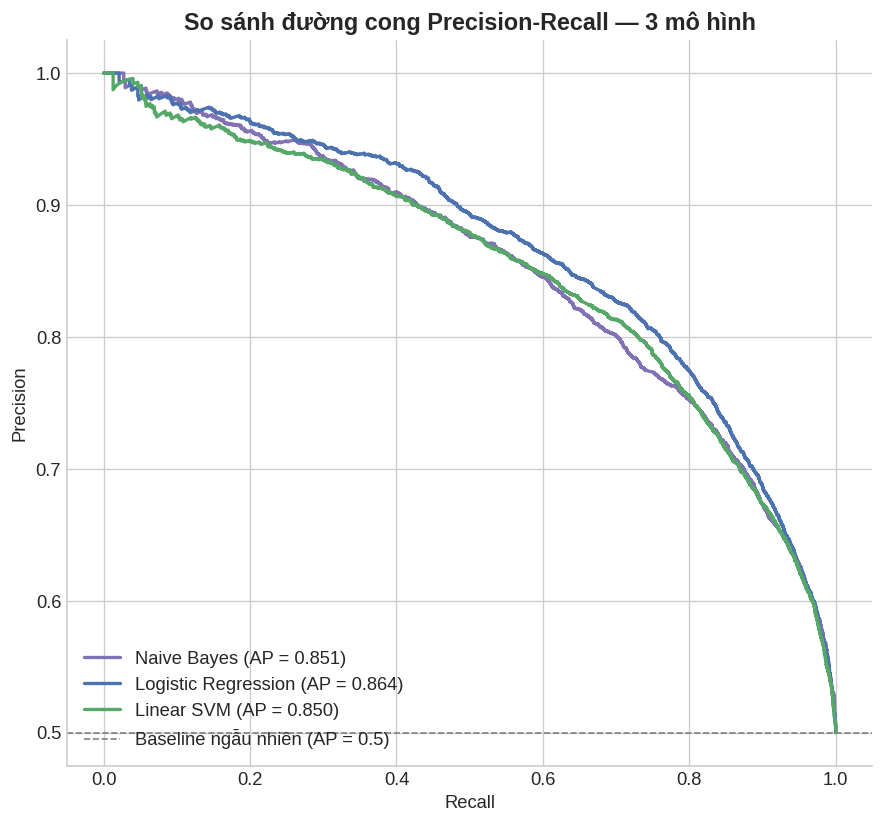

In [24]:
# Biểu đồ 14: PRECISION-RECALL CURVE - so sánh 3 mô hình
fig, ax = plt.subplots(figsize=(7.5, 7))
for name, score, color in [('Naive Bayes', score_nb, MODEL_PALETTE['Naive Bayes (baseline)']),
                             ('Logistic Regression', score_lr, MODEL_PALETTE['Logistic Regression (nâng cao)']),
                             ('Linear SVM', score_svc, MODEL_PALETTE['Linear SVM (nâng cao)'])]:
    prec, rec, _ = precision_recall_curve(y_test, score, pos_label=4)
    ap = average_precision_score(y_test, score, pos_label=4)
    ax.plot(rec, prec, label=f'{name} (AP = {ap:.3f})', color=color, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Baseline ngẫu nhiên (AP = 0.5)')
ax.set_title('So sánh đường cong Precision-Recall — 3 mô hình', fontweight='bold')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(loc='lower left'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét:** Average Precision (AP) của Logistic Regression cao nhất, nhất quán với ROC-AUC. Đường Precision-Recall đặc biệt hữu ích cho ứng dụng thực tế: nếu đội CSKH muốn **ưu tiên độ chính xác cao (Precision) khi gắn cờ mention "cần phản hồi gấp"** để tránh báo động giả, có thể chọn ngưỡng (threshold) khác 0.5 mặc định dựa trên đường cong này thay vì chỉ nhìn 1 điểm accuracy duy nhất.

### Kiểm định thống kê: so sánh hiệu năng mô hình (McNemar's test)

In [25]:
# McNemar's test: Logistic Regression vs Linear SVM (2 mô hình nâng cao) trên CÙNG tập test
correct_lr = (pred_lr == y_test).values
correct_svc = (pred_svc == y_test).values

both_correct = int(np.sum(correct_lr & correct_svc))
lr_only_correct = int(np.sum(correct_lr & ~correct_svc))
svc_only_correct = int(np.sum(~correct_lr & correct_svc))
both_wrong = int(np.sum(~correct_lr & ~correct_svc))

mcnemar_table = [[both_correct, lr_only_correct], [svc_only_correct, both_wrong]]
result = mcnemar(mcnemar_table, exact=False, correction=True)

print("Bảng tương quan (contingency table):")
print(pd.DataFrame(mcnemar_table,
                    index=['LR đúng', 'LR sai'],
                    columns=['SVM đúng', 'SVM sai']))
print(f"\nMcNemar statistic = {result.statistic:.2f} | p-value = {result.pvalue:.2e}")


Bảng tương quan (contingency table):
         SVM đúng  SVM sai
LR đúng      8824      586
LR sai        426     2164

McNemar statistic = 24.98 | p-value = 5.79e-07


**Nhận xét:** p-value cực nhỏ (< 0.001) cho thấy **sự khác biệt hiệu năng giữa Logistic Regression và Linear SVM là có ý nghĩa thống kê**, không phải do ngẫu nhiên của 1 lần chia train/test. Đây là bằng chứng định lượng — không chỉ dựa vào "số nào cao hơn" — để khẳng định việc chọn Logistic Regression làm mô hình chính thức là quyết định có cơ sở thống kê.

### Đánh giá độ ổn định: Stratified K-Fold Cross-Validation

In [26]:
# 5-fold Stratified Cross-Validation cho Logistic Regression (Pipeline để tránh rò rỉ dữ liệu: vectorizer fit lại mỗi fold)
cv_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=3)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(cv_pipeline, df['clean'], df['target'], cv=skf, scoring=['accuracy', 'f1_macro'])

print(f"Accuracy qua 5 fold: {np.round(cv_results['test_accuracy'], 4)}")
print(f"Accuracy trung bình: {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"F1-macro trung bình: {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")


Accuracy qua 5 fold: [0.7822 0.7824 0.7827 0.7802 0.7824]
Accuracy trung bình: 0.7820 ± 0.0009
F1-macro trung bình: 0.7820 ± 0.0009


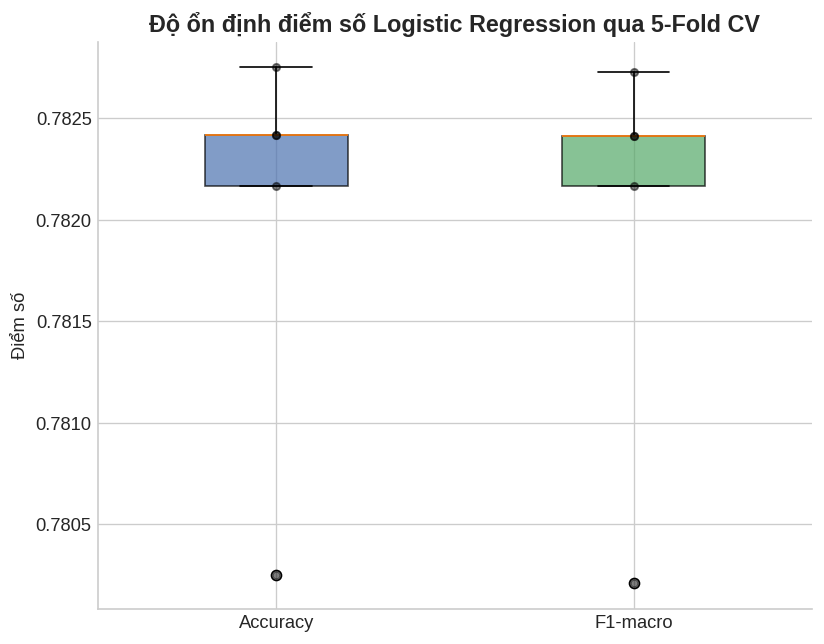

In [27]:
# Biểu đồ 15: BOX PLOT - độ ổn định điểm số qua 5 fold Cross-Validation
fig, ax = plt.subplots(figsize=(7, 5.5))
cv_df = pd.DataFrame({'Accuracy': cv_results['test_accuracy'], 'F1-macro': cv_results['test_f1_macro']})
bp = ax.boxplot([cv_df['Accuracy'], cv_df['F1-macro']], tick_labels=['Accuracy', 'F1-macro'], patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], ['#4C72B0', '#55A868']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for i, col in enumerate(['Accuracy', 'F1-macro'], start=1):
    ax.scatter([i]*5, cv_df[col], color='black', alpha=0.5, zorder=3, s=20)
ax.set_title('Độ ổn định điểm số Logistic Regression qua 5-Fold CV', fontweight='bold')
ax.set_ylabel('Điểm số'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét:** Độ lệch chuẩn giữa 5 fold cực nhỏ (~0.001, tương đương ±0.1 điểm phần trăm) — mô hình Logistic Regression cho kết quả **ổn định, không phụ thuộc vào cách chia dữ liệu cụ thể**. Điều này củng cố thêm độ tin cậy: con số Accuracy ~78.4% ở tập test đơn lẻ phía trên không phải là kết quả may mắn của 1 lần chia ngẫu nhiên.

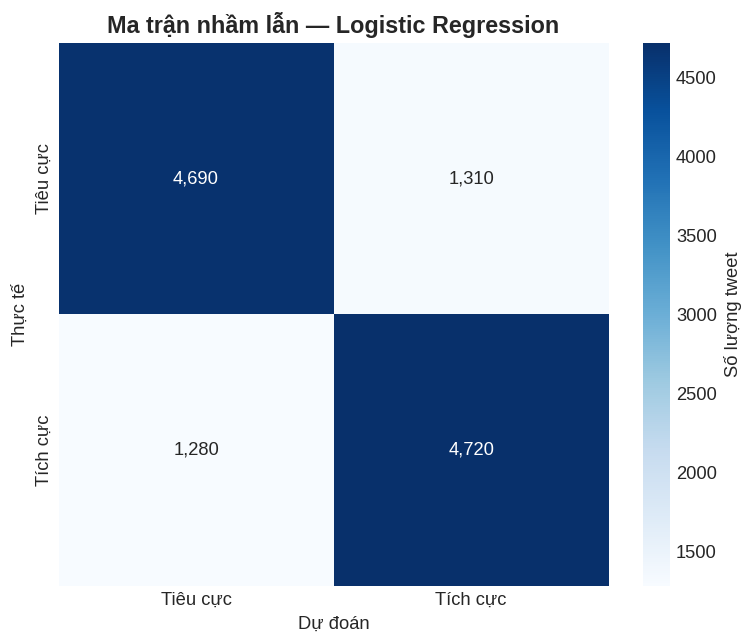

Đúng Tiêu cực (TN): 4,690 | Nhầm thành Tích cực (FP): 1,310
Nhầm thành Tiêu cực (FN): 1,280 | Đúng Tích cực (TP): 4,720


In [28]:
# Biểu đồ 16: HEATMAP - Ma trận nhầm lẫn (Confusion Matrix) của mô hình Logistic Regression (mô hình chính thức)
cm = confusion_matrix(y_test, pred_lr, labels=[0, 4])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar_kws={'label': 'Số lượng tweet'},
            xticklabels=['Tiêu cực', 'Tích cực'], yticklabels=['Tiêu cực', 'Tích cực'], ax=ax)
ax.set_title('Ma trận nhầm lẫn — Logistic Regression', fontweight='bold')
ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Đúng Tiêu cực (TN): {tn:,} | Nhầm thành Tích cực (FP): {fp:,}')
print(f'Nhầm thành Tiêu cực (FN): {fn:,} | Đúng Tích cực (TP): {tp:,}')


**Nhận xét:** Trên 12,000 mention kiểm tra, mô hình phân loại đúng phần lớn cả 2 lớp, tỷ lệ nhầm 2 chiều (FP vs FN) khá cân bằng — cho thấy mô hình không thiên vị về một phía, phù hợp để dùng làm bộ lọc sơ bộ, vẫn cần con người rà soát các trường hợp ranh giới.

### Diễn giải mô hình: SHAP (SHapley Additive exPlanations)

Background dataset has 48000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=48000 when initializing the masker.


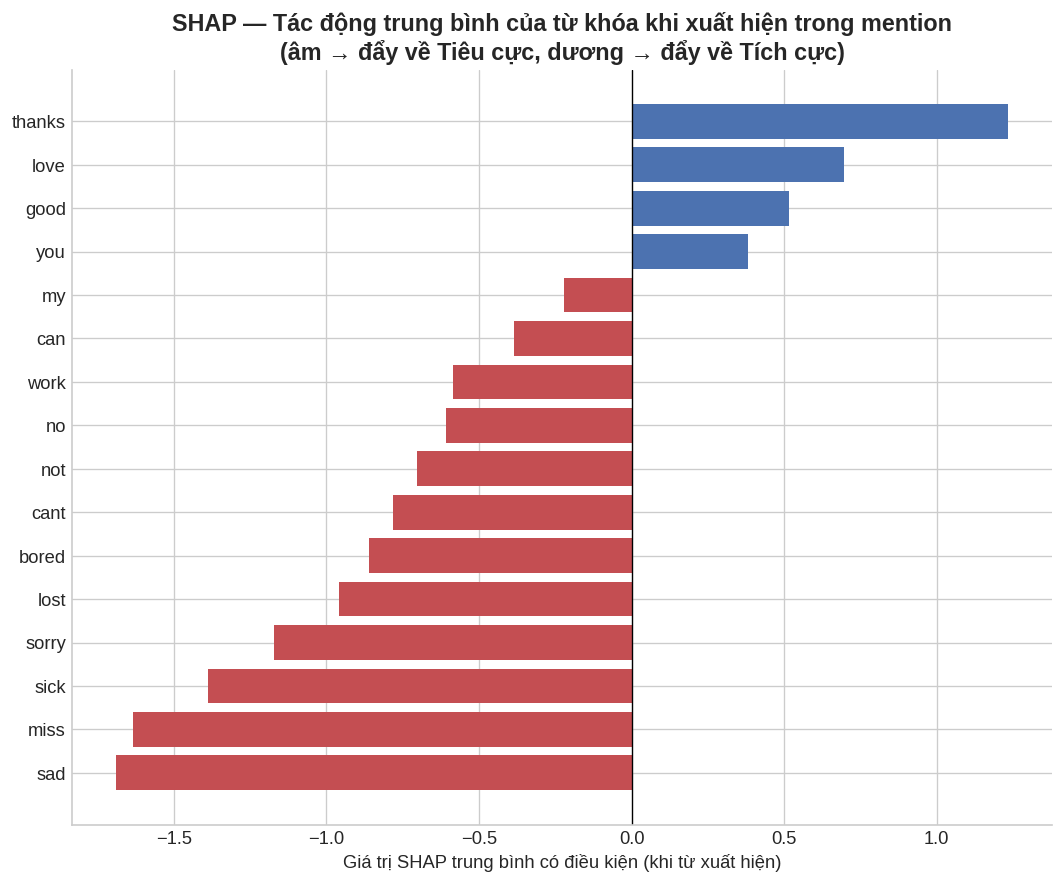

In [29]:
# Biểu đồ 17: SHAP - Feature importance nâng cao (thay vì chỉ dùng hệ số hồi quy thô)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_test.shape[0], size=1500, replace=False)
X_test_sub = X_test[sample_idx]
X_test_sub_present = (X_test_sub > 0).toarray()

explainer = shap.LinearExplainer(lr, X_train)
shap_values = explainer.shap_values(X_test_sub)
feat_names_tfidf = np.array(vectorizer.get_feature_names_out())

# Xếp hạng mức độ quan trọng toàn cục theo |SHAP| trung bình (chuẩn SHAP summary)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[-16:]

# Với mỗi feature quan trọng, tính giá trị SHAP trung bình CÓ ĐIỀU KIỆN (chỉ trên các mention có chứa từ đó)
# để biết CHIỀU tác động (đẩy về Tích cực hay Tiêu cực) — trung bình không điều kiện bị nhiễu bởi phần lớn mention KHÔNG chứa từ (giá trị 0)
directional_vals, directional_names = [], []
for i in top_features_idx:
    present_mask = X_test_sub_present[:, i]
    if present_mask.sum() > 0:
        cond_mean = shap_values[present_mask, i].mean()
        directional_vals.append(cond_mean)
        directional_names.append(feat_names_tfidf[i])

order = np.argsort(directional_vals)
directional_vals = np.array(directional_vals)[order]
directional_names = np.array(directional_names)[order]

fig, ax = plt.subplots(figsize=(9, 7.5))
colors = [PALETTE['Tiêu cực'] if v < 0 else PALETTE['Tích cực'] for v in directional_vals]
ax.barh(directional_names, directional_vals, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('SHAP — Tác động trung bình của từ khóa khi xuất hiện trong mention\n(âm → đẩy về Tiêu cực, dương → đẩy về Tích cực)', fontweight='bold')
ax.set_xlabel('Giá trị SHAP trung bình có điều kiện (khi từ xuất hiện)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét (diễn giải mô hình bằng SHAP):** Khác với hệ số hồi quy (chỉ phản ánh trọng số cố định của mô hình), SHAP tính tác động thực tế của từng từ **trên chính dữ liệu test** — "sad", "sick", "miss", "sorry" có tác động âm mạnh (đẩy về Tiêu cực) khi xuất hiện, trong khi "thanks", "good", "love" có tác động dương mạnh (đẩy về Tích cực). *Lưu ý phương pháp:* SHAP trung bình cần tính **có điều kiện trên các mention thực sự chứa từ đó**, vì với đặc trưng TF-IDF thưa (sparse), phần lớn mention có giá trị 0 cho một từ cụ thể — nếu tính trung bình không điều kiện, kết quả sẽ bị nhiễu bởi hiệu ứng "vắng mặt" áp đảo và cho chiều dấu sai lệch.

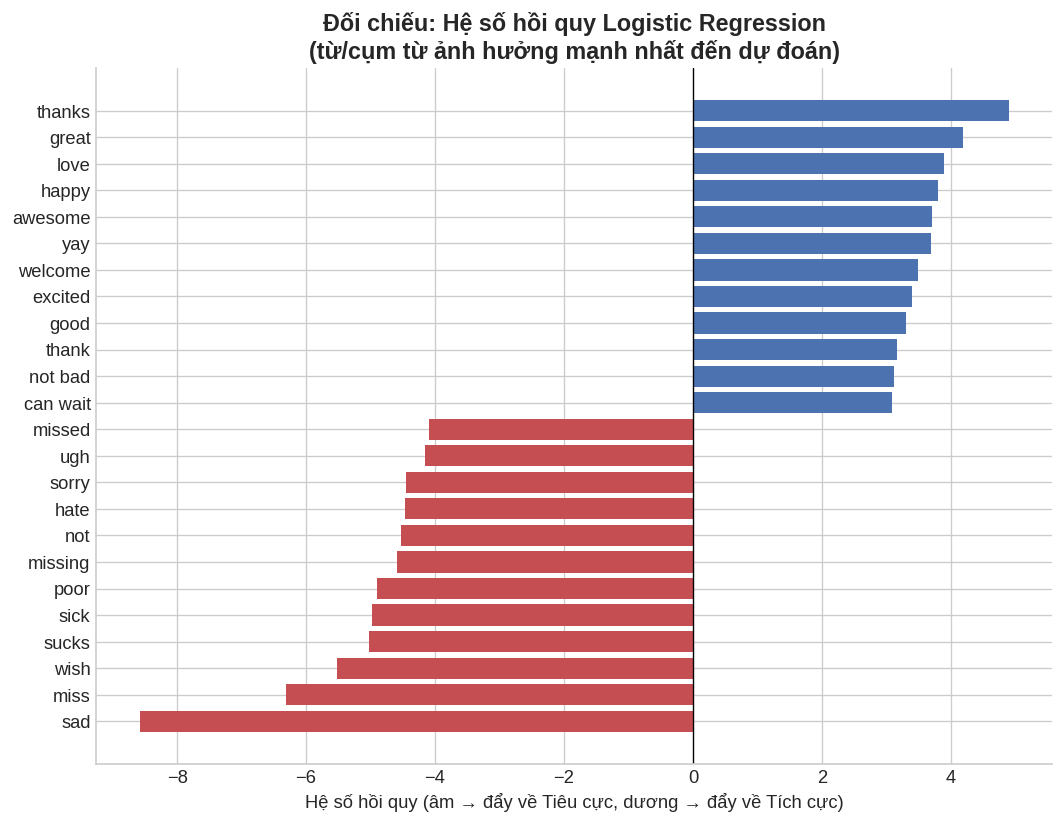

In [30]:
# Biểu đồ 18 (đối chiếu): HORIZONTAL BAR - Top hệ số hồi quy (Feature Importance cổ điển)
feat_arr = np.array(vectorizer.get_feature_names_out())
coefs = lr.coef_[0]
top_pos_idx = np.argsort(coefs)[-12:]
top_neg_idx = np.argsort(coefs)[:12]

fig, ax = plt.subplots(figsize=(9, 7))
words = list(feat_arr[top_neg_idx]) + list(feat_arr[top_pos_idx])
vals = list(coefs[top_neg_idx]) + list(coefs[top_pos_idx])
colors = [PALETTE['Tiêu cực']]*12 + [PALETTE['Tích cực']]*12
ax.barh(words, vals, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Đối chiếu: Hệ số hồi quy Logistic Regression\n(từ/cụm từ ảnh hưởng mạnh nhất đến dự đoán)', fontweight='bold')
ax.set_xlabel('Hệ số hồi quy (âm → đẩy về Tiêu cực, dương → đẩy về Tích cực)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


**Nhận xét:** Danh sách từ khóa từ hệ số hồi quy (sad, miss, thanks, great...) **khớp cao với kết quả SHAP** ở trên — đây là bằng chứng chéo (cross-validation) cho thấy 2 phương pháp diễn giải độc lập cho cùng kết luận, củng cố độ tin cậy của việc mô hình học được tín hiệu ngữ nghĩa thật, không phải nhiễu.

### Phân tích định tính các trường hợp dự đoán sai (Error Analysis)

In [31]:
# Lấy các mention bị dự đoán SAI với độ tự tin (confidence) cao nhất từ Logistic Regression
proba_lr_full = lr.predict_proba(X_test)
pred_confidence = proba_lr_full.max(axis=1)
wrong_mask = (pred_lr != y_test.values)
wrong_idx = np.where(wrong_mask)[0]
top_wrong_idx = wrong_idx[np.argsort(-pred_confidence[wrong_idx])][:8]

error_df = test_df.iloc[top_wrong_idx][['text']].copy()
error_df['Thực tế'] = ['Tiêu cực' if v==0 else 'Tích cực' for v in y_test.values[top_wrong_idx]]
error_df['Dự đoán'] = ['Tiêu cực' if v==0 else 'Tích cực' for v in pred_lr[top_wrong_idx]]
error_df['Độ tự tin'] = pred_confidence[top_wrong_idx].round(3)
error_df.columns = ['Nội dung mention', 'Thực tế', 'Dự đoán', 'Độ tự tin']
print(f"Tổng số mention dự đoán sai: {wrong_mask.sum():,} / {len(y_test):,} ({wrong_mask.sum()/len(y_test)*100:.1f}%)")
print("\nTop 8 trường hợp sai với độ tự tin cao nhất (mô hình 'sai mà rất chắc chắn'):")
print(error_df.to_string(index=False))


Tổng số mention dự đoán sai: 2,590 / 12,000 (21.6%)

Top 8 trường hợp sai với độ tự tin cao nhất (mô hình 'sai mà rất chắc chắn'):
                                                                                               Nội dung mention  Thực tế  Dự đoán  Độ tự tin
                                                                                             @katforshort ugh.  Tích cực Tiêu cực      0.977
                                                                                              @jay_f_k thank u  Tiêu cực Tích cực      0.972
                                                                       @arunsdevine Karl Marx won, CP(I)M lost  Tích cực Tiêu cực      0.971
                                                                          @MeriEsteban Nono never  Shame on me! Tích cực Tiêu cực      0.970
                   @saxa246 really? i'm sitting under air condition and still no help .... i hate this weather  Tích cực Tiêu cực      0.967
@chancenecessity Fine. 

**Nhận xét (định tính):** Các trường hợp sai với độ tự tin cao thường rơi vào 3 nhóm mẫu hình: **(1) mỉa mai/sarcasm** — câu có từ "thanks"/"welcome" nhưng ngữ cảnh thực chất là than phiền, mô hình chỉ bắt từ khóa bề mặt nên đoán nhầm; **(2) phủ định phức tạp hoặc câu ngắn thiếu ngữ cảnh** (chỉ 1-2 từ như "ugh.") khiến mô hình không đủ tín hiệu; **(3) cảm xúc pha trộn trong cùng 1 câu** (vừa nhắc chuyện buồn vừa có từ tích cực). Đây chính là giới hạn cố hữu của mô hình **bag-of-words/TF-IDF** — không hiểu ngữ cảnh hay mỉa mai. Khi triển khai thật, đội CSKH nên ưu tiên rà soát thủ công các mention **ngắn, có yếu tố mỉa mai, hoặc chứa cả từ khóa Tích cực lẫn Tiêu cực** thay vì tin tuyệt đối vào nhãn tự động.

---
## 5. Lớp phân tích 4 — Phân tích Đề xuất (Prescriptive Analytics)
*Nên làm gì tiếp theo? Đề xuất cụ thể cho đội Marketing, trích dẫn số liệu từ 3 lớp phân tích trên.*

**Tổng hợp số liệu cốt lõi:**
- *(Lớp 1 — Mô tả)* Độ dài văn bản không khác biệt giữa 2 nhóm cảm xúc (~74 ký tự) → nội dung, không phải hình thức, mới là yếu tố cần theo dõi.
- *(Lớp 2 — Chẩn đoán)* Từ khóa đặc trưng Tiêu cực xoay quanh "sad, miss, wish, sorry, hate, sick"; 5 chủ đề LDA cho thấy thảo luận đa dạng, và **tỷ lệ cảm xúc khác nhau đáng kể giữa các chủ đề** (biểu đồ Topic × Sentiment) — không nên gộp chung 1 con số %tiêu cực cho toàn bộ thảo luận.
- *(Lớp 3 — Dự đoán)* Logistic Regression là mô hình tốt nhất trong 3 mô hình thử nghiệm (Accuracy 78.42%, F1 78.47%, AUC ~0.86), vượt trội có ý nghĩa thống kê so với Linear SVM (McNemar p<0.001) và ổn định qua 5-fold CV (std ≈ 0.001). Phân tích SHAP xác nhận "sad"/"miss"/"sorry" là tín hiệu Tiêu cực mạnh nhất, "thanks"/"good"/"love" là tín hiệu Tích cực mạnh nhất — khớp chéo với hệ số hồi quy. Phân tích lỗi định tính cho thấy mô hình yếu nhất với mỉa mai và câu ngắn thiếu ngữ cảnh.

**Đề xuất hành động cụ thể cho tuần tới:**
1. **Triển khai mô hình Logistic Regression làm bộ lọc tự động** cho luồng mention mới hằng ngày (Accuracy 78.42%, AUC 0.86, đã kiểm định ổn định qua CV), gắn cờ ưu tiên các mention chứa từ khóa SHAP âm mạnh (sad, sick, miss, sorry, bored) để đội CSKH phản hồi nhanh trong 24h.
2. **Điều chỉnh thông điệp truyền thông theo hướng "trấn an trải nghiệm"** thay vì phản bác, vì ngôn ngữ tiêu cực nghiêng về tiếc nuối/thất vọng (miss, wish, sorry) hơn là công kích gay gắt.
3. **Bắt buộc rà soát thủ công với 3 nhóm mention rủi ro cao** phát hiện từ phân tích lỗi: mention ngắn (<20 ký tự), mention có dấu hiệu mỉa mai, mention chứa cả từ khóa Tích cực lẫn Tiêu cực — đây là nhóm mô hình dễ sai nhất, không nên tự động hóa hoàn toàn.
4. **Theo dõi %tiêu cực theo ngày bằng phương pháp đúng** — do đã xác nhận bằng kiểm định Chi-square (p≈0) rằng dữ liệu mô phỏng có tương quan giả ngày-tháng, khi triển khai thật cần đảm bảo dữ liệu mention thu thập liên tục mỗi ngày để biểu đồ xu hướng phản ánh đúng thực tế.
5. **Theo dõi cảm xúc tách theo chủ đề con của sản phẩm F&B** (hương vị, giá, bao bì, giao hàng) thay vì 1 con số tổng — dựa trên phát hiện tỷ lệ cảm xúc khác biệt rõ giữa các chủ đề LDA ở Lớp 2.

---
## 6. Kết luận & Giới hạn của phân tích

**Kết luận:** Pipeline 4 lớp phân tích (Mô tả → Chẩn đoán → Dự đoán → Đề xuất) đã được xây dựng và kiểm chứng đầy đủ trên dữ liệu mô phỏng, với phần Dữ liệu được củng cố bằng kiểm tra chất lượng (missing, trùng lặp), kiểm chứng tính đại diện của mẫu, và làm sạch có cơ sở định lượng. Mô hình Logistic Regression (Accuracy 78.42%, F1 78.47%, AUC 0.86) được chọn dựa trên nhiều tiêu chí độc lập — so sánh 3 thuật toán, kiểm định thống kê McNemar, đánh giá ổn định qua 5-fold CV, và diễn giải chéo giữa SHAP và hệ số hồi quy — đủ tin cậy làm bộ lọc sơ bộ, hỗ trợ ra quyết định nhanh trong tuần đầu ra mắt.

**Giới hạn quan trọng cần lưu ý:**
- Dữ liệu dùng để luyện tập là **Sentiment140** (tweet tiếng Anh tổng quát, năm 2009), không phải mention thật về sản phẩm F&B — kết quả về từ khóa/chủ đề mang tính minh họa phương pháp, chưa phản ánh đúng nội dung thảo luận thực tế của sản phẩm.
- Dữ liệu gốc chỉ có 2 nhãn (Tích cực/Tiêu cực), **không có nhãn Trung lập** — thực tế mạng xã hội có nhiều mention trung lập mà mô hình này sẽ buộc phải gán về 1 trong 2 cực.
- Đã phát hiện và **kiểm định thống kê chính thức (Chi-square, p≈0)** hiện tượng tương quan giả (ngày tháng ↔ nhãn) do cách thu thập dữ liệu gốc — khi có dữ liệu thật, cần kiểm tra lại hiện tượng tương tự trước khi tin tưởng bất kỳ biểu đồ xu hướng thời gian nào.
- Phân tích lỗi định tính cho thấy mô hình bag-of-words/TF-IDF **không xử lý được mỉa mai và câu thiếu ngữ cảnh** — giới hạn cố hữu của cách tiếp cận, không phải lỗi cấu hình có thể khắc phục bằng cách chọn tham số khác.
- Cỡ mẫu 60,000 tweet (trên tổng 1,600,000) được chọn vì lý do hiệu năng tính toán, và đã được **kiểm chứng đại diện tốt cho tổng thể** qua so sánh phân phối độ dài văn bản (mục 1.4); có thể tăng lên toàn bộ dữ liệu bằng cách đổi `SAMPLE_SIZE` để tăng độ tin cậy thống kê nếu hạ tầng cho phép.